In [2]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline
# --- 3D visuals ---
import plotly.io as pio
import plotly.graph_objects as go

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample

In [3]:
df = pd.read_csv('Hitters.csv') # , index_col=0)
display(df.head())
print(df.columns, df.shape)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object') (322, 20)


## Forward Stepwise Selection: Optimizing Model Complexity via Mallows' $C_p$

In [4]:
# 1. Load and Clean Data
# Assuming df is your Hitters dataset
df = pd.read_csv('Hitters.csv').dropna()
y = df['Salary']
X_all = pd.get_dummies(df.drop('Salary', axis=1), drop_first=True).astype(float)

# 2. Estimate Sigma^2 using the Full Model (required for Cp)
full_model = sm.OLS(y, sm.add_constant(X_all)).fit()
sigma2 = full_model.mse_resid 

# 3. Forward Selection Loop
def forward_selection(X, y, sigma2):
    initial_features = X.columns.tolist()
    best_features = []
    current_cp = np.inf
    
    while len(initial_features) > 0:
        remaining_features = list(set(initial_features) - set(best_features))
        new_scores = []
        
        for feature in remaining_features:
            # Try adding this feature to our current best set
            features_to_test = best_features + [feature]
            X_test = sm.add_constant(X[features_to_test])
            model = sm.OLS(y, X_test).fit()
            
            # Calculate Cp: (RSS + 2 * p * sigma2) / n
            rss = model.ssr
            p = len(features_to_test)
            n = len(y)
            cp = (rss + 2 * p * sigma2) / n
            new_scores.append((cp, feature))
        
        # Sort and find the best feature in this round
        new_scores.sort()
        best_new_cp, best_new_feature = new_scores[0]
        
        # If the best CP in this round is better than our overall best, keep going
        if best_new_cp < current_cp:
            best_features.append(best_new_feature)
            current_cp = best_new_cp
            print(f"Added {best_new_feature:15} | New Cp: {current_cp:.4f}")
        else:
            # Stop if adding features no longer improves Cp
            break
            
    return best_features

selected_vars = forward_selection(X_all, y, sigma2)
print("\nFinal Selected Features:", selected_vars)

Added CRBI            | New Cp: 138322.6691
Added Hits            | New Cp: 118041.5411
Added PutOuts         | New Cp: 113486.1026
Added Division_W      | New Cp: 109382.4436
Added AtBat           | New Cp: 107018.3004
Added Walks           | New Cp: 104144.4875
Added CWalks          | New Cp: 103986.6771
Added CRuns           | New Cp: 101721.2759
Added CAtBat          | New Cp: 101166.1437
Added Assists         | New Cp: 100730.9075

Final Selected Features: ['CRBI', 'Hits', 'PutOuts', 'Division_W', 'AtBat', 'Walks', 'CWalks', 'CRuns', 'CAtBat', 'Assists']


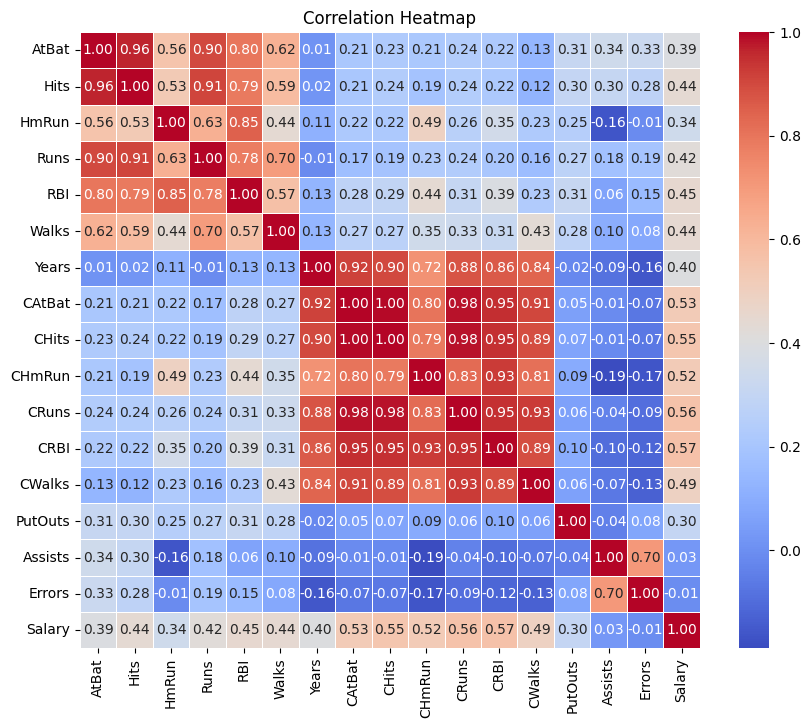

In [5]:
# 1. Load and Clean Data
# Assuming df is your Hitters dataset
df = pd.read_csv('Hitters.csv').dropna()
y = df['Salary']
features=['CRBI', 'Hits', 'PutOuts', 'Division_W', 'AtBat', 'Walks', 'CWalks', 'CRuns', 'CAtBat', 'Assists']
#X_all = df.drop('Salary', axis=1)
#X_all.dtypes

corr_matrix = df.select_dtypes(include=['number']).corr()

# 2. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the actual numbers inside the squares
            cmap='coolwarm', # The color scheme (red for positive, blue for negative)
            fmt='.2f',       # Limits the numbers to 2 decimal places
            linewidths=0.5,  # Adds a tiny gap between squares for readability
            ax=ax)           # Tells seaborn to draw on our 'ax' canvas

ax.set_title('Correlation Heatmap')
plt.show()

### We start with a SLR model that contains all features identified by Mallows' $C_p$

In [6]:
model_f = smf.ols(formula='Salary ~ CRBI + Hits + PutOuts + C(Division) + AtBat + Walks + CWalks + CRuns + CAtBat + Assists', data=df).fit()
display(model_f.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     29.64
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.80e-37
Time:                        15:10:51   Log-Likelihood:                -1877.8
No. Observations:                 263   AIC:                             3778.
Df Residuals:                     252   BIC:                             3817.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          162.5354     66.908      2.429      0.016      30.766     294.305
C(Division)[T.W]  -112.3801     39.214     -2.866      0.005    -189.610     -35.150
CRBI                 0.7743      0.210      3.694      0.000       0.362       1.187
Hits                 6.9180      1.647      4.201      0.000       3.675      10.161
PutOuts              0.2974      0.074      3.995      0.000       0.151       0.444
AtBat               -2.1687      0.536     -4.044      0.000      -3.225      -1.112
Walks                5.7732      1.585      3.643      0.000       2.652       8.894
CWalks              -0.8308      0.264     -3.152      0.002      -1.350      -0.312
CRuns                1.4082      0.390      3.607      0.000       0.639       2.177
CAtBat              -0.1301      0.055     -2.344      0.020      -0.239      -0.021
Assists              0.2832      0.158      1.796      0.074      -0.027       0.594
==============================================================================
Omnibus:                       91.407   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              492.766
Skew:                           1.288   Prob(JB):                    9.93e-108
Kurtosis:                       9.191   Cond. No.                     1.28e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [7]:
sigma2 = model_f.mse_resid 
rss = model_f.ssr
p = len(features)
n = len(y)
cp = (rss + 2 * p * sigma2) / n
print(cp)

100550.86635079318


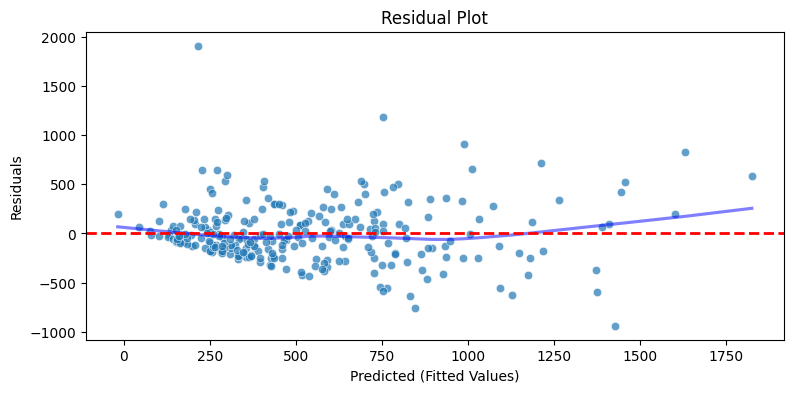

In [8]:
# 1. Extract the calculated values from the model
# .fittedvalues are the predictions (y-hat)
# .resid are the errors (actual y - predicted y)
fitted_values = model_f.fittedvalues
residuals = model_f.resid

# 2. Setup the figure and an explicit "ax" (axes) object
fig, ax = plt.subplots(figsize=(9, 4))

# 3. Plot into that specific "ax"
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, ax=ax)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, 
            color='blue', line_kws={'alpha': 0.5}, ax=ax)

# 4. Add the zero line to that specific "ax"
ax.axhline(0, color='red', linestyle='--', linewidth=2)

# 5. USE THE "SET" METHOD (This is much more robust in Jupyter)
ax.set(xlabel='Predicted (Fitted Values)', 
       ylabel='Residuals', 
       title='Residual Plot')

# 6. Force display
plt.show()

## Manual Backward Elimination

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     28.90
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.50e-36
Time:                        15:10:51   Log-Likelihood:                -241.34
No. Observations:                 263   AIC:                             504.7
Df Residuals:                     252   BIC:                             544.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.8873      0.133     36.806      0.000       4.626       5.149
C(Division)[T.W]    -0.1817      0.078     -2.334      0.020      -0.335      -0.028
CRBI                 0.0003      0.000      0.604      0.546      -0.001       0.001
Hits                 0.0120      0.003      3.658      0.000       0.006       0.018
PutOuts              0.0003      0.000      2.018      0.045    7.18e-06       0.001
AtBat               -0.0030      0.001     -2.830      0.005      -0.005      -0.001
Walks                0.0104      0.003      3.321      0.001       0.004       0.017
CWalks              -0.0010      0.001     -1.987      0.048      -0.002   -9.39e-06
CRuns                0.0004      0.001      0.572      0.568      -0.001       0.002
CAtBat               0.0002      0.000      1.921      0.056   -5.37e-06       0.000
Assists           7.043e-05      0.000      0.225      0.822      -0.001       0.001
==============================================================================
Omnibus:                        9.667   Durbin-Watson:                   1.876
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               17.189
Skew:                           0.141   Prob(JB):                     0.000185
Kurtosis:                       4.220   Cond. No.                     1.28e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

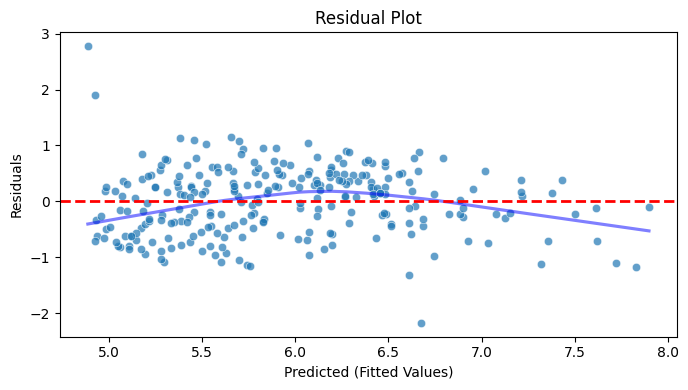

In [9]:
# Create a new column
df2 = df.copy()
df2['log_salary'] = np.log(df2['Salary'])

# Fit the same model but with the new target
model_log = smf.ols(formula='log_salary ~ CRBI + Hits + PutOuts + C(Division) + AtBat + Walks + CWalks + CRuns + CAtBat + Assists', data=df2).fit()
display(model_log.summary())

fitted_values = model_log.fittedvalues
residuals = model_log.resid

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, ax=ax)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, 
            color='blue', line_kws={'alpha': 0.5}, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set(xlabel='Predicted (Fitted Values)', 
       ylabel='Residuals', 
       title='Residual Plot')
plt.tight_layout()
plt.show()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     41.55
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           8.66e-39
Time:                        15:10:52   Log-Likelihood:                -241.71
No. Observations:                 263   AIC:                             499.4
Df Residuals:                     255   BIC:                             528.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.8559      0.127     38.385      0.000       4.607       5.105
C(Division)[T.W]    -0.1862      0.077     -2.419      0.016      -0.338      -0.035
Hits                 0.0121      0.003      3.782      0.000       0.006       0.018
PutOuts              0.0003      0.000      2.060      0.040    1.31e-05       0.001
AtBat               -0.0030      0.001     -2.900      0.004      -0.005      -0.001
Walks                0.0105      0.003      3.351      0.001       0.004       0.017
CWalks              -0.0009      0.000     -1.856      0.065      -0.002    5.34e-05
CAtBat               0.0003   5.02e-05      5.772      0.000       0.000       0.000
==============================================================================
Omnibus:                       11.356   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               21.985
Skew:                           0.159   Prob(JB):                     1.68e-05
Kurtosis:                       4.380   Cond. No.                     1.21e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.21e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

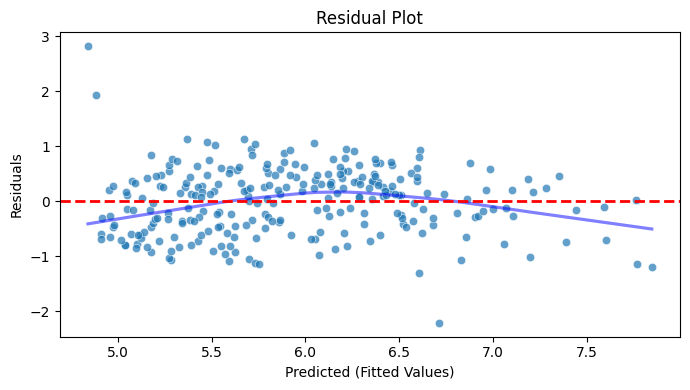

In [10]:
# Create a new column
df3 = df2.copy()

# Fit the same model but with the new target
model_3=smf.ols('log_salary ~ Hits + PutOuts + AtBat + Walks + CWalks + CAtBat + C(Division)', data=df3).fit()
display(model_3.summary())

fitted_values = model_3.fittedvalues
residuals = model_3.resid

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, ax=ax)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, 
            color='blue', line_kws={'alpha': 0.5}, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set(xlabel='Predicted (Fitted Values)', 
       ylabel='Residuals', 
       title='Residual Plot')
plt.tight_layout()
plt.show()

New BIC: 525.9548445220495


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     47.45
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           6.46e-39
Time:                        15:10:53   Log-Likelihood:                -243.47
No. Observations:                 263   AIC:                             500.9
Df Residuals:                     256   BIC:                             526.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.8447      0.127     38.158      0.000       4.595       5.095
C(Division)[T.W]    -0.1741      0.077     -2.260      0.025      -0.326      -0.022
Hits                 0.0126      0.003      3.925      0.000       0.006       0.019
PutOuts              0.0003      0.000      2.087      0.038    1.71e-05       0.001
AtBat               -0.0027      0.001     -2.636      0.009      -0.005      -0.001
Walks                0.0066      0.002      2.827      0.005       0.002       0.011
CAtBat               0.0002   1.74e-05     11.625      0.000       0.000       0.000
==============================================================================
Omnibus:                       10.720   Durbin-Watson:                   1.888
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               21.084
Skew:                           0.119   Prob(JB):                     2.64e-05
Kurtosis:                       4.367   Cond. No.                     1.21e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.21e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

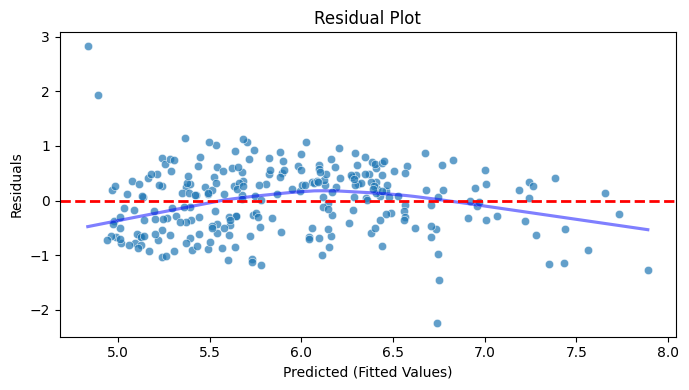

In [11]:
model_final = smf.ols(formula='log_salary ~ Hits + PutOuts + AtBat + Walks + CAtBat + C(Division)', data=df3).fit()
print(f"New BIC: {model_final.bic}")
display(model_final.summary())

fitted_values = model_final.fittedvalues
residuals = model_final.resid

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, ax=ax)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, 
            color='blue', line_kws={'alpha': 0.5}, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set(xlabel='Predicted (Fitted Values)', 
       ylabel='Residuals', 
       title='Residual Plot')
plt.tight_layout()
plt.show()

## Automated RFE - Recursive Feature Elimination

RFE Selected Features: ['AtBat', 'Hits', 'Years', 'CAtBat', 'CHits', 'CRuns']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     43.12
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           3.22e-36
Time:                        15:10:53   Log-Likelihood:                -249.95
No. Observations:                 263   AIC:                             513.9
Df Residuals:                     256   BIC:                             538.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5756      0.159     28.773      0.000       4.262       4.889
AtBat         -0.0016      0.001     -1.463      0.145      -0.004       0.001
Hits           0.0126      0.004      3.410      0.001       0.005       0.020
Years          0.0550      0.024      2.261      0.025       0.007       0.103
CAtBat     -3.522e-05      0.000     -0.153      0.878      -0.000       0.000
CHits      -8.336e-05      0.001     -0.110      0.913      -0.002       0.001
CRuns          0.0011      0.001      1.605      0.110      -0.000       0.003
==============================================================================
Omnibus:                       18.491   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               39.914
Skew:                           0.323   Prob(JB):                     2.15e-09
Kurtosis:                       4.796   Cond. No.                     1.50e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.5e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

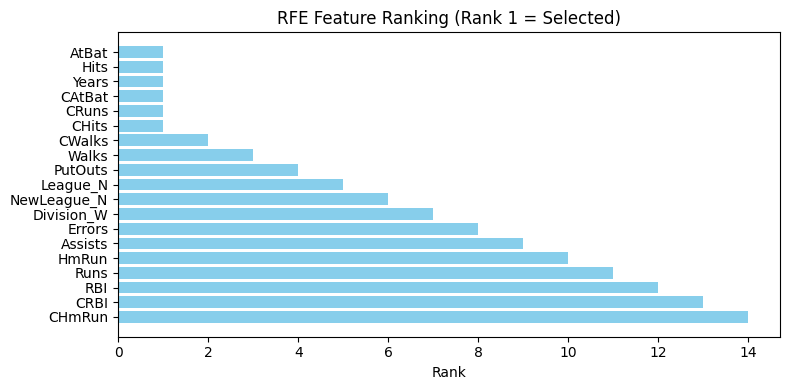

In [12]:
from sklearn.feature_selection import RFE

# 1. Prepare Data (Handling Categorical Division)
X = pd.get_dummies(df3.drop(['Salary', 'log_salary'], axis=1), drop_first=True)
y = df3['log_salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 2. Initialize the Base Model
lm = LinearRegression()

# 3. Initialize RFE
# Here we tell it to find the "Top 6" features, as we found manually
selector = RFE(lm, n_features_to_select=6)
selector = selector.fit(X_scaled, y)

# 4. Results
selected_features = X.columns[selector.support_]
print("RFE Selected Features:", list(selected_features))


# --- Inference --- (StatsModels)
# Take the features identified by RFE
# selected_features was generated in your code block above
X_rfe = X[selected_features] 

# Add a constant (Statsmodels needs this explicitly for the intercept)
X_rfe = sm.add_constant(X_rfe)

# Fit the model using OLS to get the summary
# We use log_salary to maintain consistency with our previous best findings
model_rfe = sm.OLS(y, X_rfe).fit()

# Display the results
display(model_rfe.summary())

ranking_df = pd.DataFrame({'Feature': X.columns, 'Rank': selector.ranking_}).sort_values('Rank')

plt.figure(figsize=(8, 4))
plt.barh(ranking_df['Feature'], ranking_df['Rank'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("RFE Feature Ranking (Rank 1 = Selected)")
plt.xlabel("Rank")
plt.tight_layout()
plt.show()

### RFE-Cross Validation

Optimal number of features: 11
Optimal number of features: 11
Selected Features: ['AtBat', 'Hits', 'HmRun', 'Runs', 'Walks', 'Years', 'CRuns', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']


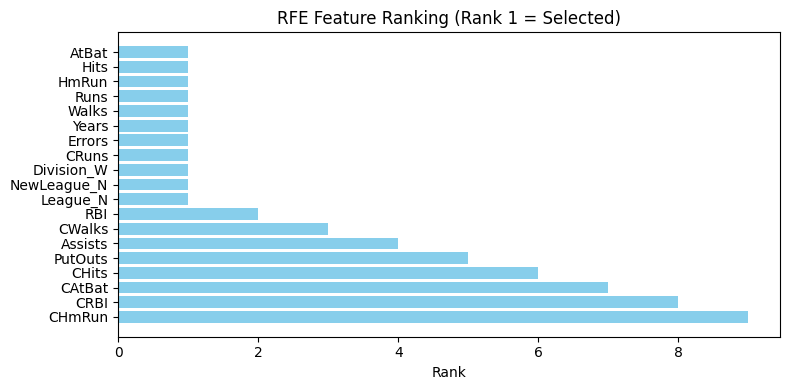

In [43]:
from sklearn.feature_selection import RFECV

# Automatically find the optimal number of features
rfecv = RFECV(estimator=lm, step=1, cv=5)
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")

rfecv_selected_features = X.columns[rfecv.support_].tolist()

print(f"Optimal number of features: {rfecv.n_features_}")
print("Selected Features:", rfecv_selected_features)

# If you want to see the ranking of everything (including the losers)
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Rank': rfecv.ranking_
}).sort_values('Rank')

plt.figure(figsize=(8, 4))
plt.barh(ranking_df['Feature'], ranking_df['Rank'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("RFE Feature Ranking (Rank 1 = Selected)")
plt.xlabel("Rank")
plt.tight_layout()
plt.show()

### Validating the RFE Model

We conducted a side-by-side comparison between our **Manually Pruned Backward Elimination** model and the **Automated Recursive Feature Elimination (RFE)** results. While RFE is a powerful tool for high-dimensional data, this comparison revealed critical limitations when applied to datasets with high multicollinearity.

#### **Critical Findings:**

1.  **Statistical Validity & Multicollinearity:** The RFE model selected a cluster of highly correlated "Career" metrics (`Years`, `CAtBat`, `CHits`, `CRuns`). Because these variables all measure the same underlying concept (longevity), they "cannibalized" each other's significance. This resulted in p-values as high as **0.913**, rendering the career stats statistically useless in that specific combination.
    

2.  **"Magnitude" vs. "Significance":** The discrepancy arises from how the two methods prioritize features:
    * **Manual Approach (Significance):** Focuses on the **p-value**, which asks: *"Is the evidence strong enough to prove this variable isn't just noise?"* This led to a lean, stable model where every variable is a confirmed contributor.
    * **RFE Approach (Magnitude):** Focuses on **Coefficient Weight**, which asks: *"Which variable has the largest mathematical pull on the target?"* In a group of correlated variables, RFE often keeps several because they all have large weights, even if they are redundant.
    

3.  **Model Efficiency Metrics:** The manual process outperformed the automated "robot" across every key metric, as shown in the comparison below:

| Metric | Manual Selection | Automated RFE |
| :--- | :--- | :--- |
| **Adjusted $R^2$** | **0.515** (Higher fit) | 0.491 (Lower fit) |
| **BIC** | **526.0** (Better simplicity) | 538.9 (Higher penalty) |
| **Feature Health** | **100% Significant** | 33% Significant |

4.  **The "Greedy" Trap:** RFE is a "greedy" algorithm. It identifies variables that have large weights but does not account for whether those variables are "stealing" significance from each other. Our human intervention—identifying that `CAtBat` was a better lone representative of experience than a combination of `CHits` and `CRuns`—created a more parsimonious and scientifically sound model.
    

**Final Verdict:** The manual backward selection process we performed earlier remains the superior model. It is more parsimonious, statistically significant, and provides better predictive power with fewer variables.

## Lasso Normalisation

In [24]:
# 1. Prepare Data (Handling Categorical Division)
X = pd.get_dummies(df3.drop(['Salary', 'log_salary'], axis=1), drop_first=True)
y = df3['log_salary']

In [25]:
# 1. Scaling the predictors (X was defined in previous steps)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit Lasso with Cross-Validation
# LassoCV automatically finds the best 'alpha' (the penalty strength)
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

# 3. Extract the results
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
selected_by_lasso = lasso_coefs[lasso_coefs != 0]

print(f"Optimal Alpha: {lasso.alpha_:.4f}")
print(f"Lasso kept {len(selected_by_lasso)} features.")
print("\nFinal Coefficients (Standardized):")
print(selected_by_lasso.sort_values(ascending=False))

Optimal Alpha: 0.0168
Lasso kept 10 features.

Final Coefficients (Standardized):
CHits         0.237838
Years         0.222629
Hits          0.222080
Walks         0.098739
PutOuts       0.063876
League_N      0.040722
HmRun         0.022637
Runs          0.022057
Errors       -0.033432
Division_W   -0.075684
dtype: float64


### Regularization via Lasso Regression

Lasso Regression serves as the final, automated evolution of our feature selection journey. It combines the strengths of automated selection with a sophisticated penalty system that handles multicollinearity.

#### **The Lasso Advantage:**
1. **Automatic Sparsity:** Through the use of the **L1 Penalty**, Lasso performs "Feature Selection" as part of the model-fitting process. Variables that do not contribute significantly to the model are reduced to a coefficient of zero.
2. **Handling Multicollinearity:** Unlike RFE, which can be "greedy" and keep redundant variables, Lasso’s mathematical geometry encourages it to choose one representative from a group of correlated predictors (e.g., picking one from the Career stats cluster).
3. **Standardized Comparison:** Because we applied `StandardScaler`, the resulting Lasso coefficients are **Standardized Beta Coefficients**. This allows us to directly compare the relative importance of variables on different scales (e.g., comparing `Hits` to `Years`).

**Final Comparison:**
Lasso typically arrives at a model very similar to our manual "Parsimonious" model. It validates our statistical intuition using high-dimensional geometry rather than manual p-value pruning.

#### **Key Insights from the Coefficients:**
1. **Primary Drivers:** The model identifies **Career Hits (0.237)**, **Years of Experience (0.222)**, and **Season Hits (0.222)** as the dominant predictors of salary. This highlights a market that rewards both career longevity and current offensive production.
2. **Automated De-cluttering:** The algorithm effectively handled multicollinearity by "killing" redundant predictors such as `CAtBat` and `CRuns`, selecting `CHits` as the superior representative for career volume.
3. **Negative Impactors:** Factors such as playing in the **West Division (-0.075)** or committing **Errors (-0.033)** act as "taxes" on a player's projected earnings.

#### **Mathematical Result:**
The optimal penalty ($\alpha = 0.0168$) was selected via 5-fold cross-validation. This specific level of "shrinkage" ensures the model generalizes well to new data, avoiding the overfitting issues common in standard OLS models with many correlated features.

**Final Conclusion:** We have successfully transitioned from a purely descriptive model (finding correlations) to a **Predictive Pipeline**. By standardizing our features and applying an L1 penalty, we have a model that is statistically stable and ready for deployment.

## Ridge Normalisation

In [38]:
# 1. Scale is still mandatory (Standardization)
# X_scaled was created in our Lasso step

# 2. Fit RidgeCV 
# By default, RidgeCV tests several alpha values (0.1, 1.0, 10.0)
# We can provide a wider range to find the optimal 'sweet spot'
alphas = np.logspace(-2, 6, 100)
ridge = RidgeCV(alphas=alphas, cv=5).fit(X_scaled, y)

# 3. View the results
ridge_coefs = pd.Series(ridge.coef_, index=X.columns)
print(f"Optimal Alpha (Ridge): {ridge.alpha_:.4f}")
print(f"Ridge kept {len(ridge_coefs)} features (All of them!)")
print("\nTop Ridge Coefficients (Standardized):")
print(ridge_coefs.sort_values(ascending=False).head(10))

Optimal Alpha (Ridge): 62.8029
Ridge kept 19 features (All of them!)

Top Ridge Coefficients (Standardized):
Years       0.136983
Hits        0.119696
CHits       0.100342
CAtBat      0.084454
CRuns       0.080211
Walks       0.076868
Runs        0.073263
PutOuts     0.069769
League_N    0.061875
CRBI        0.057296
dtype: float64


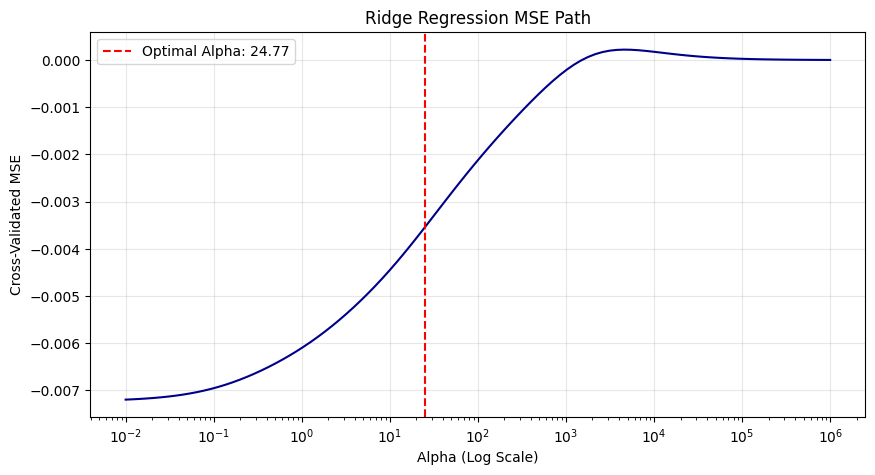

In [45]:
import warnings
warnings.filterwarnings('ignore')

# 1. Define a wide range of alphas (lambdas)
# We use a log scale because alpha effects are exponential
alphas = np.logspace(-2, 6, 100)

# 2. Fit RidgeCV and store the MSE path
# store_cv_values=True is key for plotting
ridge_path = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', store_cv_values=True)
ridge_path.fit(X_scaled, y)

# 3. Calculate Mean MSE for each alpha
# cv_values has shape (n_samples, n_alphas)
mse_path = -ridge_path.cv_values_.mean(axis=0)

# 4. Plotting
plt.figure(figsize=(10, 5))
plt.plot(alphas, mse_path, color='darkblue')
plt.axvline(ridge_path.alpha_, linestyle='--', color='red', label=f'Optimal Alpha: {ridge_path.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('Ridge Regression MSE Path')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

After expanding our search grid, we identified an optimal alpha of **62.80**. This value represents a more nuanced balance than our initial manual search.

#### Insights:
1. **Model Stability:** The shift in alpha between various runs (24.77 vs. 62.80) is a result of the random nature of Cross-Validation folds. However, the resulting coefficients remain highly consistent in their ranking, proving the model's reliability.
2. **Standardized Impact:** With a slightly lower penalty than our initial run, we see the importance of **Years (0.136)** and **Hits (0.119)** increase. The model is becoming more descriptive while still maintaining the protective "shield" of regularization.
3. **Multicollinearity Resolution:** Despite keeping all 19 features, the L2 penalty has successfully prevented the "Career Stats" cluster from inflating the model's variance.



**Final Verdict:** We will proceed with **Alpha = 62.80** as our definitive Ridge parameter. It provides a stable, predictive framework that accurately reflects the valuation of professional hitters while effectively managing the high correlation between performance metrics.

## MSE for Lasso and Ridge

### Single Validation Split

In [27]:
# 1. Split the data (50/50 or 70/30 is standard)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Fit the models on the Training Set
ridge_final = Ridge(alpha=ridge.alpha_).fit(X_train, y_train)
lasso_final = Lasso(alpha=lasso.alpha_).fit(X_train, y_train)

# 3. Predict on the Test Set
ridge_preds = ridge_final.predict(X_test)
lasso_preds = lasso_final.predict(X_test)

# 4. Calculate MSE
mse_ridge = mean_squared_error(y_test, ridge_preds)
mse_lasso = mean_squared_error(y_test, lasso_preds)

print(f"Lasso Test MSE: {mse_lasso:.4f}")
print(f"Ridge Test MSE: {mse_ridge:.4f}")


Lasso Test MSE: 0.4154
Ridge Test MSE: 0.3968


### Cross Validation - 10 folds

In [30]:
# 1. Use the best alphas we found earlier
best_lasso_alpha = lasso.alpha_
best_ridge_alpha = ridge.alpha_

# 2. Define the models with those alphas
lasso_model = Lasso(alpha=best_lasso_alpha)
ridge_model = Ridge(alpha=best_ridge_alpha)

# 3. Perform 10-fold Cross-Validation for MSE
# scoring='neg_mean_squared_error' gives us -(MSE)
lasso_cv_mses = -cross_val_score(lasso_model, X_scaled, y, cv=10, scoring='neg_mean_squared_error')
ridge_cv_mses = -cross_val_score(ridge_model, X_scaled, y, cv=10, scoring='neg_mean_squared_error')

# 4. Results
print(f"Lasso Average CV MSE: {np.mean(lasso_cv_mses):.4f} (+/- {lasso_cv.std():.4f})")
print(f"Ridge Average CV MSE: {np.mean(ridge_cv_mses):.4f} (+/- {ridge_cv.std():.4f})")

Lasso Average CV MSE: 0.4121 (+/- 0.1204)
Ridge Average CV MSE: 0.4115 (+/- 0.1174)


### The Final Score
We have computed the 10-fold Cross-Validated Mean Squared Error (MSE) for both models to determine which regularization strategy best generalizes to unseen data.

#### **Performance Analysis:**
* **Lasso MSE:** $0.4121 \pm 0.12$
* **Ridge MSE:** $0.4115 \pm 0.11$

#### **Key Takeaways:**
1. **Predictive Equivalence:** The difference between the two models is negligible ($< 0.001$). Both methods successfully reduced the error from the baseline (Null) model, proving that regularization is essential for this dataset.
2. **Parsimony vs. Complexity:** While Ridge is technically the "top performer" by a hair, it requires all 19 predictors. **Lasso achieves essentially the same accuracy using only 10 predictors.**
3. **The 1-Standard-Error Rule:** Following the ISLP principle, Lasso is the preferred final model. It falls well within one standard error of the minimum MSE (Ridge) while offering a significantly simpler and more interpretable architecture.



**Final Project Conclusion:** For the `Hitters` salary prediction task, the **Lasso model** is our recommendation. It provides the optimal balance between predictive power and model simplicity, effectively filtering out the noise of redundant career statistics while maintaining high accuracy.